# Performance comparison between Swiftlet and Lark parsing library

Import required library

In [1]:
import random as rnd

import pandas as pd
import seaborn as sns
import timeit
import cProfile


import swiftlet
import lark

Text expression generator

In [2]:
def gen_text_expr(n):
    expr = "{}".format(rnd.randint(1, n))
    opt = ["+", "-", "*", "/"]

    for _ in range(n):
        expr += " {} {}".format(rnd.choice(opt), str(rnd.randint(1, n)))
    return expr.strip()

texts = [gen_text_expr(10 * i) for i in range(1, 500)]

## Swiftlet Parser function

In [3]:
def parser_swiftlet(text: str):
    _grammar = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import (WS, INT)
    %ignore WS
    """
    parser = swiftlet.Swiftlet(grammar=_grammar, algorithm="clr")
    ast = parser.parse(text)
    return ast

## Lark Parser function

In [4]:
def parser_lark(text: str):
    _grammar = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import common.WS
    %import common.INT
    %ignore WS
    """
    _lark_parser = lark.Lark(_grammar, parser="lalr", keep_all_tokens=True)
    lark_ast = _lark_parser.parse(text=text)
    return lark_ast

In [5]:
number = 1000

In [6]:
array = []
for txt in texts[::100]:
    swiftlet_time = 1000 * timeit.timeit(lambda: parser_swiftlet(txt), number=number) / number
    lark_time = 1000 * timeit.timeit(lambda: parser_lark(txt), number=number) / number
    array.append([len(txt), swiftlet_time, lark_time])

   Text Length  swiftlet       lark
0           43  0.884065   3.971115
1         5962  2.370348   9.545215
2        12975  3.834917  14.775897
3        19953  5.543647  20.381663
4        26938  6.876013  25.536027


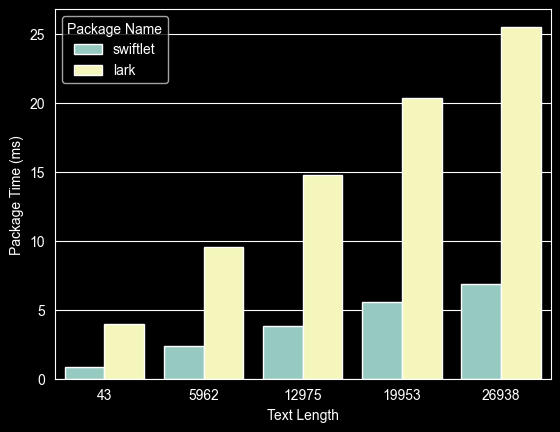

In [17]:
def grid_graph(array: list):
    df = pd.DataFrame(array, columns=['Text Length', 'swiftlet', 'lark'])
    print(df)

    sns.barplot(df.melt(
        id_vars=['Text Length'],
        value_vars=['swiftlet', 'lark'],
        var_name='Package Name',
        value_name='Package Time (ms)',
    ),
        x="Text Length",
        y="Package Time (s)",
        hue="Package Name",
    )
grid_graph(array)

In [8]:
# -------------- Swiftlet ------------------ #
grammar_swiftlet = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import (WS, INT)
    %ignore WS
    """
swiftlet_parser = swiftlet.Swiftlet(grammar=grammar_swiftlet, algorithm="clr")

# -------------- Lark ------------------ #
grammar = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import common.WS
    %import common.INT
    %ignore WS
    """
lark_parser = lark.Lark(grammar, parser="lalr", keep_all_tokens=True)


In [9]:
arr_parsed = []
for txt in texts[::100]:
    swiftlet_time = 1000 * timeit.timeit(lambda: swiftlet_parser.parse(txt), number=number) / number
    lark_time = 1000 * timeit.timeit(lambda: lark_parser.parse(txt), number=number) / number
    arr_parsed.append([len(txt), swiftlet_time, lark_time])

   Text Length  swiftlet       lark
0           43  0.018887   0.062044
1         5962  1.503429   5.652750
2        12975  2.955349  10.944660
3        19953  4.559839  16.896413
4        26938  6.063624  22.186183


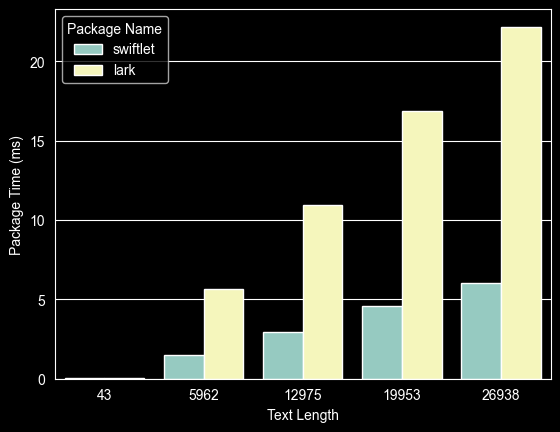

In [18]:
grid_graph(arr_parsed)

In [11]:
cProfile.run('parser_swiftlet(texts[98])')

         5 function calls in 0.003 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.002    0.002    0.003    0.003 2891851176.py:1(parser_swiftlet)
        1    0.000    0.000    0.003    0.003 <string>:1(<module>)
        1    0.000    0.000    0.003    0.003 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        1    0.001    0.001    0.001    0.001 {method 'parse' of 'swiftlet._core.Swiftlet' objects}




In [12]:
cProfile.run('parser_lark(texts[98])')

         106730 function calls (105276 primitive calls) in 0.039 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.038    0.038 595936109.py:1(parser_lark)
        2    0.000    0.000    0.000    0.000 <frozen _collections_abc>:576(_from_iterable)
        2    0.000    0.000    0.000    0.000 <frozen _collections_abc>:599(__or__)
       10    0.000    0.000    0.000    0.000 <frozen _collections_abc>:602(<genexpr>)
        8    0.000    0.000    0.000    0.000 <frozen abc>:117(__instancecheck__)
        1    0.000    0.000    0.001    0.001 <frozen importlib._bootstrap_external>:1127(get_data)
        1    0.000    0.000    0.000    0.000 <frozen importlib.util>:74(find_spec)
        1    0.000    0.000    0.000    0.000 <frozen posixpath>:150(dirname)
        4    0.000    0.000    0.000    0.000 <frozen posixpath>:41(_get_sep)
        3    0.000    0.000    0.000    0.000 <frozen posixpath>:

In [13]:
len(texts)

499

In [14]:
ast_lark = parser_lark("4 + 3 * 6 - 8 / 2")
print(ast_lark.pretty())

start
  sub
    add
      expr
        factors	4
      +
      mul
        factors	3
        *
        6
    -
    div
      factors	8
      /
      2



In [15]:
ast_rust = parser_swiftlet("4 + 3 * 6 - 8 / 2")
ast_rust.pretty_print()

 start
   sub
     add
       expr
         factors   4
       +
       mul
         factors   3
         *
         6
     -
     div
       factors   8
       /
       2
